# Provider Comparison: Multi-Source Data Acquisition

**Docker image**: `ml4t`

## Purpose
Demonstrate the `ml4t.data.providers` unified `fetch_ohlcv()` interface
across YahooFinance, WikiPrices and FRED, then build a fallback strategy
and a price-level provider-comparison report. The notebook seeds the
ETF rotation universe used by the ETFs case study downstream.

## Learning Objectives
- Fetch OHLCV from multiple providers with one call signature.
- Build a priority-ordered fallback fetcher for production resilience.
- Quantify provider disagreement (row counts, price-difference stats)
  so multi-source stitching is auditable.
- Use FRED (vintage-aware) to pull macro series for risk overlays.

## Book reference
Chapter 2, §2.3 (multi-source stitching). The ETF universe materialised
here feeds the `case_studies/etfs/` pipeline.

## Prerequisites
- Network access for live YahooFinance + FRED calls (the notebook is a
  provider-acquisition demo — these are the only places in the
  publication pass where live API calls are intentional).
- WikiPrices parquet under `ML4T_DATA_PATH/equities/market/us_equities/us_equities.parquet`
  for the historical leg.
- `FRED_API_KEY` set (free signup) for §8.

In [1]:
"""Provider Comparison — Multi-source data acquisition with ml4t-data providers."""

import os
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.data.providers import WikiPricesProvider, YahooFinanceProvider
from ml4t.data.providers.fred import FREDProvider

HAS_FRED = bool(os.getenv("FRED_API_KEY"))
if not HAS_FRED:
    raise RuntimeError(
        "FRED_API_KEY not set. Get a free key at "
        "https://fred.stlouisfed.org/docs/api/api_key.html and export it."
    )

# Reproducibility: a fixed as-of date keeps outputs stable between book
# editions. Bump when the book is revised.
AS_OF_DATE = "2025-01-15"

In [2]:
# Production defaults — Papermill injects overrides for CI

---

## Section 1: Understanding the Provider Architecture

ml4t-data provides a **unified interface** for fetching data from multiple sources. All providers inherit from `BaseProvider` and implement the same `fetch_ohlcv()` method.

### Key Benefits:
1. **Consistency**: Same API regardless of data source
2. **Validation**: Automatic OHLC invariant checks
3. **Polars Output**: 10-100x faster than pandas alternatives
4. **Rate Limiting**: Built-in throttling to avoid API bans
5. **Circuit Breaker**: Automatic failure detection and recovery

In [3]:
# The ml4t-data provider landscape
# Note: This notebook demonstrates Yahoo, WikiPrices, and FRED. Other providers
# are available but require API keys and are covered in asset-class-specific notebooks.
providers_info = pl.DataFrame(
    {
        "provider": [
            "YahooFinanceProvider",
            "WikiPricesProvider",
            "FREDProvider",
            "EODHDProvider",
            "BinanceAPIProvider",
        ],
        "asset_class": [
            "US Equities, ETFs",
            "US Equities (Historical)",
            "Economic Indicators",
            "Global Equities",
            "Crypto",
        ],
        "api_key_required": [
            "No",
            "No (local file)",
            "Yes (free)",
            "Yes (free tier)",
            "No",
        ],
        "date_range": ["~30 years", "1962-2018", "50+ years", "~20 years", "~5 years"],
        "demonstrated_in": [
            "this notebook",
            "this notebook",
            "this notebook",
            "10_crypto_perps_eda",
            "10_crypto_perps_eda",
        ],
    }
)
providers_info

provider,asset_class,api_key_required,date_range,demonstrated_in
str,str,str,str,str
"""YahooFinanceProvider""","""US Equities, ETFs""","""No""","""~30 years""","""this notebook"""
"""WikiPricesProvider""","""US Equities (Historical)""","""No (local file)""","""1962-2018""","""this notebook"""
"""FREDProvider""","""Economic Indicators""","""Yes (free)""","""50+ years""","""this notebook"""
"""EODHDProvider""","""Global Equities""","""Yes (free tier)""","""~20 years""","""10_crypto_perps_eda"""
"""BinanceAPIProvider""","""Crypto""","""No""","""~5 years""","""10_crypto_perps_eda"""


---

## Section 2: Fetching Data with Yahoo Finance

Yahoo Finance is the easiest starting point - no API key required. Let's fetch our ETF universe for the momentum strategy.

In [4]:
# Define our ETF universe for the rotation strategy
ETF_UNIVERSE = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD"]

# Date range: 5 years of daily data (relative to AS_OF_DATE for reproducibility)
end_date = AS_OF_DATE
start_date = (datetime.strptime(AS_OF_DATE, "%Y-%m-%d") - timedelta(days=5 * 365)).strftime(
    "%Y-%m-%d"
)

print(f"Fetching data from {start_date} to {end_date}")
print(f"ETF Universe: {ETF_UNIVERSE}")

Fetching data from 2020-01-17 to 2025-01-15
ETF Universe: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD']


In [5]:
# Create Yahoo Finance provider
yahoo = YahooFinanceProvider()

# Fetch SPY as our primary example
spy_data = yahoo.fetch_ohlcv("SPY", start_date, end_date)

print(f"Fetched {len(spy_data)} rows of SPY data")
print(f"Date range: {spy_data['timestamp'].min()} to {spy_data['timestamp'].max()}")
print("\nSample data:")
print(spy_data.head())

2026-06-15 22:30:42 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=yahoo


2026-06-15 22:30:42 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-15 22:30:42 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=daily name=YahooFinanceProvider provider=yahoo start=2020-01-17 symbol=SPY


2026-06-15 22:30:42 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2020-01-17 symbol=SPY


2026-06-15 22:30:42 [info     ] Successfully fetched data      rows=1256 symbol=SPY


2026-06-15 22:30:42 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1256 symbol=SPY


Fetched 1256 rows of SPY data
Date range: 2020-01-17 00:00:00 to 2025-01-15 00:00:00

Sample data:
shape: (5, 7)
┌─────────────────────┬────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ timestamp           ┆ symbol ┆ open       ┆ high       ┆ low        ┆ close      ┆ volume    │
│ ---                 ┆ ---    ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│ datetime[μs]        ┆ str    ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞═════════════════════╪════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ 2020-01-17 00:00:00 ┆ SPY    ┆ 303.129932 ┆ 303.56857  ┆ 302.353138 ┆ 303.358398 ┆ 9.5846e7  │
│ 2020-01-21 00:00:00 ┆ SPY    ┆ 302.398832 ┆ 303.568582 ┆ 302.325735 ┆ 302.764374 ┆ 7.77424e7 │
│ 2020-01-22 00:00:00 ┆ SPY    ┆ 303.623379 ┆ 304.272245 ┆ 302.645561 ┆ 302.800903 ┆ 4.89149e7 │
│ 2020-01-23 00:00:00 ┆ SPY    ┆ 302.152111 ┆ 303.559476 ┆ 301.037192 ┆ 303.148224 ┆ 5.1963e7  │
│ 2020-01-24 0

In [6]:
# Examine the schema - ml4t-data provides consistent column names
print("Schema (consistent across all providers):")
for name, dtype in spy_data.schema.items():
    print(f"  {name}: {dtype}")

Schema (consistent across all providers):
  timestamp: Datetime(time_unit='us', time_zone=None)
  symbol: String
  open: Float64
  high: Float64
  low: Float64
  close: Float64
  volume: Float64


In [7]:
# Fetch the full ETF universe — fail loudly on missing tickers
etf_data = {symbol: yahoo.fetch_ohlcv(symbol, start_date, end_date) for symbol in ETF_UNIVERSE}
print(
    f"Fetched {len(etf_data)}/{len(ETF_UNIVERSE)} ETFs · "
    f"{sum(len(d) for d in etf_data.values()):,} total daily rows"
)

2026-06-15 22:30:42 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=daily name=YahooFinanceProvider provider=yahoo start=2020-01-17 symbol=SPY


2026-06-15 22:30:42 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2020-01-17 symbol=SPY


2026-06-15 22:30:42 [info     ] Successfully fetched data      rows=1256 symbol=SPY


2026-06-15 22:30:42 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1256 symbol=SPY


2026-06-15 22:30:42 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=daily name=YahooFinanceProvider provider=yahoo start=2020-01-17 symbol=QQQ


...

2026-06-15 22:30:44 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=daily name=YahooFinanceProvider provider=yahoo start=2020-01-17 symbol=GLD


2026-06-15 22:30:44 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2020-01-17 symbol=GLD


2026-06-15 22:30:44 [info     ] Successfully fetched data      rows=1256 symbol=GLD


2026-06-15 22:30:44 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1256 symbol=GLD


Fetched 7/7 ETFs · 8,790 total daily rows


In [8]:
# Combine into a single DataFrame with symbol column
combined_dfs = []
for symbol, df in etf_data.items():
    combined_dfs.append(df.with_columns(pl.lit(symbol).alias("symbol")))

etf_universe_df = pl.concat(combined_dfs).sort(["symbol", "timestamp"])

(
    etf_universe_df.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("start"),
        pl.col("timestamp").max().alias("end"),
        pl.len().alias("rows"),
        pl.col("close").last().alias("last_close"),
    )
    .sort("symbol")
)

symbol,start,end,rows,last_close
str,datetime[μs],datetime[μs],u32,f64
"""EEM""",2020-01-17 00:00:00,2025-01-15 00:00:00,1256,40.613529
"""EFA""",2020-01-17 00:00:00,2025-01-15 00:00:00,1255,72.309586
"""GLD""",2020-01-17 00:00:00,2025-01-15 00:00:00,1256,248.880005
"""IWM""",2020-01-17 00:00:00,2025-01-15 00:00:00,1256,220.630417
"""QQQ""",2020-01-17 00:00:00,2025-01-15 00:00:00,1256,513.445312
"""SPY""",2020-01-17 00:00:00,2025-01-15 00:00:00,1256,584.303894
"""TLT""",2020-01-17 00:00:00,2025-01-15 00:00:00,1255,81.521393


---

## Section 3: Historical Data with WikiPrices

For long-term backtests (30+ years), Yahoo Finance has limitations. WikiPrices provides
long-horizon U.S. equity history (including many delisted names) from roughly 1962 to 2018.

**Key Advantage**: Includes delisted companies, but you still need explicit survivorship
checks and delisting return handling (see `08_survivorship_bias_detection`).

In [9]:
from utils import ML4T_DATA_PATH

WIKI_PATHS = [
    # Primary: canonical layout under ML4T_DATA_PATH
    ML4T_DATA_PATH / "equities" / "market" / "us_equities" / "us_equities.parquet",
    # Docker mount (same nested layout)
    Path("/data/equities/market/us_equities/us_equities.parquet"),
    # Test fixture (CI subset)
    Path("tests/fixtures/data/equities/market/us_equities/us_equities.parquet"),
    Path("tests/fixtures/data/equities/market/us_equities/us_equities.parquet"),
]

wiki = None
wiki_path_used = None
wiki_load_errors = []

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

### WikiPrices Schema Adapter

When WikiPrices data has been canonicalized to `symbol`/`timestamp` columns,
this adapter provides the same `fetch_ohlcv()` interface as the library provider.

In [10]:
class CanonicalWikiPricesAdapter:
    """Adapter for canonicalized local Wiki Prices parquet."""

    def __init__(self, parquet_path: Path):
        self.parquet_path = Path(parquet_path)

    def fetch_ohlcv(self, symbol: str, start: str, end: str) -> pl.DataFrame:
        start_date = datetime.strptime(start, "%Y-%m-%d").date()
        end_date = datetime.strptime(end, "%Y-%m-%d").date()
        return (
            pl.scan_parquet(self.parquet_path)
            .filter(
                (pl.col("symbol") == symbol)
                & pl.col("timestamp").is_between(start_date, end_date, closed="both")
            )
            .select(
                [
                    pl.col("timestamp").cast(pl.Datetime("us")).alias("timestamp"),
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "adj_close",
                    "adj_open",
                    "adj_high",
                    "adj_low",
                    "adj_volume",
                    "ex_dividend",
                    "split_ratio",
                ]
            )
            .sort("timestamp")
            .collect()
        )

    def list_available_symbols(self) -> list[str]:
        return (
            pl.scan_parquet(self.parquet_path)
            .select(pl.col("symbol").unique().sort())
            .collect()
            .to_series()
            .to_list()
        )

    def close(self) -> None:
        """Mirror provider lifecycle API."""
        return None

### Load WikiPrices Provider

Try multiple paths to find WikiPrices data (local install, Docker, CI fixtures).

In [11]:
for wiki_path in WIKI_PATHS:
    if wiki_path.exists():
        print(f"  Found: {wiki_path}")
        try:
            wiki = WikiPricesProvider(parquet_path=wiki_path)
            wiki_path_used = wiki_path
            break
        except Exception as e:
            # File exists but failed to load - this is a real error, not silent skip
            wiki_load_errors.append((wiki_path, str(e)))
            print(f"  ERROR loading {wiki_path}: {e}")

# If we found files but couldn't load any of them, that's a bug - fail loudly
if wiki is None and wiki_load_errors:
    error_msg = "WikiPrices files found but failed to load:\n"
    for path, err in wiki_load_errors:
        error_msg += f"  {path}: {err}\n"
    raise RuntimeError(error_msg)

  Found: data/equities/market/us_equities/us_equities.parquet
2026-06-15 22:30:45 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=wiki_prices


2026-06-15 22:30:45 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-15 22:30:45 [info     ] Initialized Wiki Prices provider cache_in_memory=False name=WikiPricesProvider parquet_path=data/equities/market/us_equities/us_equities.parquet


2026-06-15 22:30:45 [debug    ] Using lazy loading (minimal memory footprint) name=WikiPricesProvider


In [12]:
if wiki is None:
    raise RuntimeError(
        f"WikiPrices parquet not found in any of: {[str(p) for p in WIKI_PATHS]}. "
        "Materialise it via WikiPricesProvider.download(api_key=<nasdaq>) first."
    )

print(f"WikiPrices loaded from: {wiki_path_used}")

# Fetch long-term AAPL history; the canonical local schema may need the
# adapter wrapper if the file uses asset/date instead of symbol/timestamp.
try:
    aapl_historical = wiki.fetch_ohlcv("AAPL", "1990-01-01", "2018-03-27")
except Exception as e:
    if 'unable to find column "ticker"' not in str(e):
        raise
    print("Detected canonical schema; switching to CanonicalWikiPricesAdapter.")
    wiki = CanonicalWikiPricesAdapter(wiki_path_used)
    aapl_historical = wiki.fetch_ohlcv("AAPL", "1990-01-01", "2018-03-27")

print(
    f"AAPL data: {len(aapl_historical)} rows · "
    f"{aapl_historical['timestamp'].min()} → {aapl_historical['timestamp'].max()}"
)
aapl_historical.head()

WikiPrices loaded from: data/equities/market/us_equities/us_equities.parquet
2026-06-15 22:30:45 [info     ] Fetching OHLCV data            end=2018-03-27 frequency=daily name=WikiPricesProvider provider=wiki_prices start=1990-01-01 symbol=AAPL


2026-06-15 22:30:45 [info     ] Fetched Wiki Prices data       date_range='1990-01-02 00:00:00 to 2018-03-27 00:00:00' name=WikiPricesProvider rows=7113 symbol=AAPL


2026-06-15 22:30:45 [info     ] Successfully fetched OHLCV data name=WikiPricesProvider provider=wiki_prices rows=7113 symbol=AAPL


AAPL data: 7113 rows · 1990-01-02 00:00:00 → 2018-03-27 00:00:00


timestamp,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
1990-01-02 00:00:00,1.058061,1.125597,1.050557,1.118093,4.57996e7
1990-01-03 00:00:00,1.140605,1.140605,1.125597,1.125597,5.19988e7
1990-01-04 00:00:00,1.148109,1.163117,1.118093,1.129499,5.53784e7
1990-01-05 00:00:00,1.133101,1.148109,1.110589,1.133101,3.0828e7
1990-01-08 00:00:00,1.125597,1.140605,1.110589,1.140605,2.53932e7


In [13]:
# WikiPrices includes delisted companies — critical for avoiding survivorship bias.
available_symbols = wiki.list_available_symbols()
print(f"WikiPrices contains {len(available_symbols):,} symbols; sample: {available_symbols[:10]}")

2026-06-15 22:30:45 [debug    ] Listed available symbols       count=3199 name=WikiPricesProvider


WikiPrices contains 3,199 symbols; sample: ['A', 'AA', 'AAL', 'AAMC', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT']


---

## Section 4: Multi-Provider Fallback Strategy

For production systems, we need a robust strategy that handles:
1. API failures
2. Rate limits
3. Data gaps
4. Historical coverage

The **fallback pattern** tries providers in order until one succeeds.

In [14]:
@dataclass
class FetchResult:
    """Result of a multi-provider fetch attempt."""

    success: bool
    data: pl.DataFrame | None
    provider_used: str | None
    providers_tried: list[str]
    error_messages: dict[str, str]

### Fallback Fetch

Try multiple providers in priority order; return the first successful result.

In [15]:
def fetch_with_fallback(
    symbol: str,
    start: str,
    end: str,
    providers: list,
    provider_names: list[str],
) -> FetchResult:
    """
    Fetch data trying multiple providers in order.

    Parameters
    ----------
    symbol : str
        Ticker symbol
    start, end : str
        Date range (YYYY-MM-DD)
    providers : list
        Provider instances to try
    provider_names : list[str]
        Names for logging

    Returns
    -------
    FetchResult
        Result with data and metadata
    """
    errors = {}
    tried = []

    for provider, name in zip(providers, provider_names, strict=False):
        tried.append(name)
        try:
            data = provider.fetch_ohlcv(symbol, start, end)
            if len(data) > 0:
                return FetchResult(
                    success=True,
                    data=data,
                    provider_used=name,
                    providers_tried=tried,
                    error_messages=errors,
                )
            else:
                errors[name] = "Empty result"
        except Exception as e:
            errors[name] = str(e)

    return FetchResult(
        success=False,
        data=None,
        provider_used=None,
        providers_tried=tried,
        error_messages=errors,
    )

In [16]:
# Try Yahoo first, then WikiPrices as fallback
providers = [yahoo, wiki]
provider_names = ["Yahoo Finance", "WikiPrices"]

result = fetch_with_fallback("AAPL", "2020-01-01", "2020-12-31", providers, provider_names)
if not result.success:
    raise RuntimeError(f"All providers failed: {result.error_messages}")
print(
    f"Success via {result.provider_used}: {len(result.data):,} rows; tried {result.providers_tried}"
)

2026-06-15 22:30:45 [info     ] Fetching OHLCV data            end=2020-12-31 frequency=daily name=YahooFinanceProvider provider=yahoo start=2020-01-01 symbol=AAPL


2026-06-15 22:30:45 [info     ] Fetching data from Yahoo Finance end=2021-01-01 interval=1d start=2020-01-01 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched data      rows=253 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=253 symbol=AAPL


Success via Yahoo Finance: 253 rows; tried ['Yahoo Finance']


---

## Section 5: Combining Historical and Recent Data

For 30+ year backtests, we combine:
1. **WikiPrices** (1962-2018) - includes delisted names
2. **Yahoo Finance** (2018-present) - current data

This gives us the best of both worlds.

In [17]:
def build_complete_history(
    symbol: str,
    yahoo_provider,
    wiki_provider=None,
    start_date: str = "1990-01-01",
    end_date: str = None,
) -> pl.DataFrame:
    """Build complete OHLCV history combining WikiPrices (pre-2018) and Yahoo Finance (2018+)."""
    if end_date is None:
        end_date = AS_OF_DATE

    parts = []

    # WikiPrices cutoff
    wiki_end = "2018-03-27"

    # Part 1: Historical data from WikiPrices
    if wiki_provider and start_date < wiki_end:
        try:
            historical = wiki_provider.fetch_ohlcv(symbol, start_date, wiki_end)
            if len(historical) > 0:
                parts.append(historical)
                print(f"  WikiPrices: {len(historical)} rows ({start_date} to {wiki_end})")
        except Exception as e:
            print(f"  WikiPrices: {e}")

    # Part 2: Recent data from Yahoo Finance
    yahoo_start = "2018-03-28" if start_date < wiki_end else start_date
    try:
        recent = yahoo_provider.fetch_ohlcv(symbol, yahoo_start, end_date)
        if len(recent) > 0:
            parts.append(recent)
            print(f"  Yahoo Finance: {len(recent)} rows ({yahoo_start} to {end_date})")
    except Exception as e:
        print(f"  Yahoo Finance: {e}")

    if not parts:
        raise ValueError(f"No data found for {symbol}")

    # Standardize columns and types before concatenation
    # Both providers should have: timestamp, open, high, low, close, volume
    standard_cols = ["timestamp", "open", "high", "low", "close", "volume"]
    standardized = []
    for df in parts:
        # Select only standard columns (ensure all have same schema)
        df_std = df.select(standard_cols)
        # Normalize types: timestamp to us precision, numerics to Float64
        df_std = df_std.with_columns(
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("open", "high", "low", "close").cast(pl.Float64),
            pl.col("volume").cast(
                pl.Float64
            ),  # Volume can be Int64 or Float64 depending on provider
        )
        standardized.append(df_std)

    # Combine and deduplicate
    combined = pl.concat(standardized).sort("timestamp").unique("timestamp")
    print(f"  Combined: {len(combined)} rows total")

    return combined

In [18]:
# Build complete AAPL history (1990-now)
aapl_complete = build_complete_history("AAPL", yahoo, wiki, "1990-01-01")
print(
    f"Combined: {len(aapl_complete):,} rows · "
    f"{aapl_complete['timestamp'].min()} → {aapl_complete['timestamp'].max()}"
)

2026-06-15 22:30:46 [info     ] Fetching OHLCV data            end=2018-03-27 frequency=daily name=WikiPricesProvider provider=wiki_prices start=1990-01-01 symbol=AAPL


2026-06-15 22:30:46 [info     ] Fetched Wiki Prices data       date_range='1990-01-02 00:00:00 to 2018-03-27 00:00:00' name=WikiPricesProvider rows=7113 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched OHLCV data name=WikiPricesProvider provider=wiki_prices rows=7113 symbol=AAPL


  WikiPrices: 7113 rows (1990-01-01 to 2018-03-27)
2026-06-15 22:30:46 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=daily name=YahooFinanceProvider provider=yahoo start=2018-03-28 symbol=AAPL


2026-06-15 22:30:46 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2018-03-28 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched data      rows=1711 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1711 symbol=AAPL


  Yahoo Finance: 1711 rows (2018-03-28 to 2025-01-15)
  Combined: 8824 rows total
Combined: 8,824 rows · 1990-01-02 00:00:00 → 2025-01-15 00:00:00


---

## Section 6: Provider Data Comparison

Yahoo Finance and WikiPrices both expose a close price, but they apply different
adjustment conventions and cover different date ranges, so the two series can
diverge sharply. This section demonstrates how to:

1. Align data from multiple providers by date
2. Quantify differences (row counts, price discrepancies)
3. Identify systematic vs random variations
4. Diagnose the causes (splits, dividends, timing)

**Why this matters**: Multi-source strategies must understand when providers disagree.
Small discrepancies compound over backtests; large ones signal data errors.

In [19]:
def compare_providers_detailed(
    symbol: str,
    start: str,
    end: str,
    provider_a,
    provider_b,
    name_a: str = "Provider A",
    name_b: str = "Provider B",
) -> dict:
    """
    Detailed comparison of two data providers for a symbol.

    Returns dict with:
    - summary: high-level stats
    - aligned: row-by-row comparison DataFrame
    - discrepancies: rows where providers disagree significantly
    """
    try:
        data_a = provider_a.fetch_ohlcv(symbol, start, end)
        data_b = provider_b.fetch_ohlcv(symbol, start, end)
    except Exception as e:
        return {"error": str(e), "summary": None, "aligned": None, "discrepancies": None}

    # Normalize timestamps to date for joining (providers may have different time components)
    data_a = data_a.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
    data_b = data_b.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))

    # Inner join on date to get overlapping rows
    aligned = data_a.select(["timestamp", "open", "high", "low", "close", "volume"]).join(
        data_b.select(["timestamp", "open", "high", "low", "close", "volume"]),
        on="timestamp",
        suffix="_b",
    )

    # Calculate differences
    aligned = aligned.with_columns(
        [
            ((pl.col("close") - pl.col("close_b")) / pl.col("close_b") * 100).alias(
                "close_diff_pct"
            ),
            ((pl.col("volume") - pl.col("volume_b")) / pl.col("volume_b") * 100).alias(
                "volume_diff_pct"
            ),
        ]
    )

    # Identify significant discrepancies (>0.1% price difference)
    discrepancies = aligned.filter(pl.col("close_diff_pct").abs() > 0.1)

    # Summary statistics
    summary = {
        "symbol": symbol,
        "period": f"{start} to {end}",
        f"{name_a}_rows": len(data_a),
        f"{name_b}_rows": len(data_b),
        "aligned_rows": len(aligned),
        "missing_in_a": len(data_b) - len(aligned),
        "missing_in_b": len(data_a) - len(aligned),
        "mean_close_diff_pct": aligned["close_diff_pct"].mean() if len(aligned) > 0 else None,
        "max_close_diff_pct": aligned["close_diff_pct"].abs().max() if len(aligned) > 0 else None,
        "discrepancy_days": len(discrepancies),
        "exact_matches": len(aligned.filter(pl.col("close_diff_pct").abs() < 0.01)),
    }

    return {"summary": summary, "aligned": aligned, "discrepancies": discrepancies}

In [20]:
comparison_result = compare_providers_detailed(
    "AAPL", "2017-01-01", "2017-12-31", yahoo, wiki, "Yahoo", "WikiPrices"
)
if comparison_result.get("error"):
    raise RuntimeError(f"Comparison failed: {comparison_result['error']}")

summary = comparison_result["summary"]
summary_df = pl.DataFrame([summary])
summary_df

2026-06-15 22:30:46 [info     ] Fetching OHLCV data            end=2017-12-31 frequency=daily name=YahooFinanceProvider provider=yahoo start=2017-01-01 symbol=AAPL


2026-06-15 22:30:46 [info     ] Fetching data from Yahoo Finance end=2018-01-01 interval=1d start=2017-01-01 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched data      rows=251 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=251 symbol=AAPL


2026-06-15 22:30:46 [info     ] Fetching OHLCV data            end=2017-12-31 frequency=daily name=WikiPricesProvider provider=wiki_prices start=2017-01-01 symbol=AAPL


2026-06-15 22:30:46 [info     ] Fetched Wiki Prices data       date_range='2017-01-03 00:00:00 to 2017-12-29 00:00:00' name=WikiPricesProvider rows=249 symbol=AAPL


2026-06-15 22:30:46 [info     ] Successfully fetched OHLCV data name=WikiPricesProvider provider=wiki_prices rows=249 symbol=AAPL


symbol,period,Yahoo_rows,WikiPrices_rows,aligned_rows,missing_in_a,missing_in_b,mean_close_diff_pct,max_close_diff_pct,discrepancy_days,exact_matches
str,str,i64,i64,i64,i64,i64,f64,f64,i64,i64
"""AAPL""","""2017-01-01 to 2017-12-31""",251,249,249,0,2,-76.694946,76.723726,249,0


In [21]:
# Show top discrepancies (if any)
disc = comparison_result["discrepancies"]
if len(disc) > 0:
    disc.select(["timestamp", "close", "close_b", "close_diff_pct"]).head(5)
else:
    print("No significant Yahoo↔WikiPrices price discrepancies for AAPL 2017.")

### What Real Provider Discrepancies Look Like

When comparing Yahoo Finance to WikiPrices on historical data, common findings include:

| Pattern | Typical Magnitude | Cause |
|---------|-------------------|-------|
| **Exact match** | <0.01% | Same underlying source |
| **Small drift** | 0.01-0.1% | Rounding, adjustment timing |
| **Step change** | 1-10% | Different split adjustment date |
| **Systematic offset** | Consistent % | Different dividend treatment |

**Key insight**: Raw quotes share the same exchange source, but *adjustments*
diverge — and that divergence can dominate the comparison. The AAPL 2017 run
above is a case in point: all 249 overlapping days differ by ~77% (zero exact
matches) because Yahoo's close retroactively reflects Apple's 2020 4:1 split,
while WikiPrices ends in 2018 and never applied it. Always align the adjustment
basis (and watch the coverage window) before diffing two providers.

---

## Section 7: ETF Universe Performance

We visualize the 7 core ETFs defined at the start of this notebook. These represent
distinct asset classes for the rotation strategy:

| Symbol | Asset Class | Role in Portfolio |
|--------|-------------|-------------------|
| SPY | US Large Cap | Risk-on equity |
| QQQ | US Tech | High-beta growth |
| IWM | US Small Cap | Cyclical exposure |
| EFA | Intl Developed | Geographic diversification |
| EEM | Emerging Markets | Growth/risk allocation |
| TLT | Long Treasury | Flight-to-quality |
| GLD | Gold | Inflation/crisis hedge |

A rotation strategy switches between these based on momentum signals (Chapter 7).

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(
.venv/lib/python3.14/site-packages/kaleido/scopes/base.py:188: DeprecationWarning: setDaemon() is deprecated, set the daemon attribute instead
  self._std_error_thread.setDaemon(True)


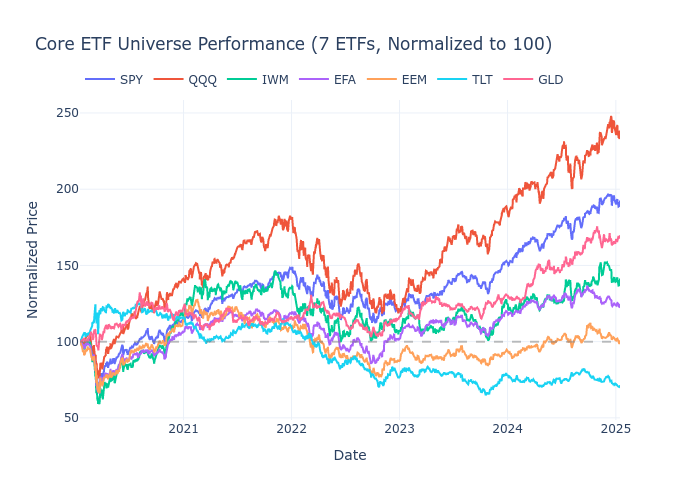

In [22]:
# Calculate normalized prices (start = 100)
fig = go.Figure()

for symbol, df in etf_data.items():
    # Normalize to 100 at start
    normalized = (df["close"] / df["close"][0]) * 100

    fig.add_trace(
        go.Scatter(
            x=df["timestamp"].to_list(),
            y=normalized.to_list(),
            name=symbol,
            mode="lines",
        )
    )

fig.update_layout(
    title=f"Core ETF Universe Performance ({len(etf_data)} ETFs, Normalized to 100)",
    xaxis_title="Date",
    yaxis_title="Normalized Price",
    height=500,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)

# Add horizontal line at 100
fig.add_hline(y=100, line_dash="dash", line_color="gray", opacity=0.5)

fig.show()

In [23]:
# Calculate performance statistics
performance_stats = []

for symbol, df in etf_data.items():
    returns = df["close"].pct_change().drop_nulls()

    total_return = (df["close"][-1] / df["close"][0] - 1) * 100
    annual_return = ((1 + total_return / 100) ** (252 / len(df)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (annual_return - 2) / volatility if volatility > 0 else 0  # Assume 2% risk-free

    performance_stats.append(
        {
            "symbol": symbol,
            "total_return_pct": total_return,
            "annual_return_pct": annual_return,
            "volatility_pct": volatility,
            "sharpe_ratio": sharpe,
            "trading_days": len(df),
        }
    )

performance_df = pl.DataFrame(performance_stats).sort("annual_return_pct", descending=True)
performance_df

symbol,total_return_pct,annual_return_pct,volatility_pct,sharpe_ratio,trading_days
str,f64,f64,f64,f64,i64
"""QQQ""",138.506054,19.052995,25.708193,0.663329,1256
"""SPY""",92.611741,14.055932,21.043152,0.572915,1256
"""GLD""",69.791241,11.206328,15.540726,0.5924,1256
"""IWM""",41.332958,7.18756,27.423975,0.189162,1256
"""EFA""",24.841419,4.555894,19.942371,0.128164,1255
"""EEM""",0.848621,0.16969,22.417459,-0.081647,1256
"""TLT""",-28.575264,-6.534082,17.974035,-0.474801,1255


---

## Section 8: Economic Data with FREDProvider

For macro regime detection and risk management, FRED (Federal Reserve Economic Data)
provides 800,000+ economic time series. Key series for trading include:

| Series | Description | Frequency |
|--------|-------------|-----------|
| VIXCLS | VIX Volatility Index | Daily |
| DGS10 | 10-Year Treasury Yield | Daily |
| T10Y2Y | Yield Curve Slope | Daily |
| UNRATE | Unemployment Rate | Monthly |
| ICSA | Initial Jobless Claims | Weekly |

**Get free API key**: https://fred.stlouisfed.org/docs/api/api_key.html

In [24]:
# Pull VIX and 10Y Treasury from FRED for the same window
fred = FREDProvider()
vix = fred.fetch_ohlcv("VIXCLS", "2023-01-01", "2024-01-01")
treasury_10y = fred.fetch_ohlcv("DGS10", "2023-01-01", "2024-01-01")
fred.close()

vix_mean = float(vix["close"].mean())
vix_max = float(vix["close"].max())
last_yield = float(treasury_10y.filter(pl.col("close").is_not_null())["close"][-1])
print(
    f"VIX 2023: {len(vix):,} obs · mean {vix_mean:.1f}, max {vix_max:.1f} · "
    f"DGS10 last yield {last_yield:.2f}%"
)
vix.head()

2026-06-15 22:30:47 [debug    ] Rate limiter initialized       max_calls=100 period=60.0 provider=fred


2026-06-15 22:30:47 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-15 22:30:47 [info     ] Initialized FRED provider      name=FREDProvider


2026-06-15 22:30:47 [info     ] Fetching daily OHLCV           end=2024-01-01 name=FREDProvider start=2023-01-01 symbol=VIXCLS vintage_date=None


2026-06-15 22:30:48 [info     ] Fetched 261 records            name=FREDProvider symbol=VIXCLS


2026-06-15 22:30:48 [info     ] Fetching daily OHLCV           end=2024-01-01 name=FREDProvider start=2023-01-01 symbol=DGS10 vintage_date=None


2026-06-15 22:30:48 [info     ] Fetched 261 records            name=FREDProvider symbol=DGS10


VIX 2023: 261 obs · mean 16.8, max 26.5 · DGS10 last yield 3.88%


timestamp,symbol,open,high,low,close,volume
datetime[μs],str,f64,f64,f64,f64,f64
2023-01-02 00:00:00,"""VIXCLS""",null,null,null,null,1.0
2023-01-03 00:00:00,"""VIXCLS""",22.9,22.9,22.9,22.9,1.0
2023-01-04 00:00:00,"""VIXCLS""",22.01,22.01,22.01,22.01,1.0
2023-01-05 00:00:00,"""VIXCLS""",22.46,22.46,22.46,22.46,1.0
2023-01-06 00:00:00,"""VIXCLS""",21.13,21.13,21.13,21.13,1.0


## Key Takeaways

Multi-source data acquisition profile for the 7-ETF rotation universe.

### Quantitative Findings
- **ETF universe** (5 years, 1,256 trading days/symbol): QQQ
  +138.5 % total return / +19.1 % annualised / Sharpe 0.66 leads;
  TLT −28.6 % / −6.5 % / Sharpe −0.47 trails. EEM essentially flat
  (+0.85 % total, Sharpe −0.08). The 5-year window covers a
  bond-bear / equity-bull regime — useful for the rotation case study
  to learn that "diversification" requires non-equity diversifiers
  beyond duration alone.
- **WikiPrices coverage**: ~3,200 historical symbols (1962-2018)
  including delisted names — required for any backtest that wants to
  avoid survivorship bias on legacy data.
- **Yahoo↔WikiPrices comparison (AAPL 2017)**: zero exact matches — all
  249 overlapping days differ by ~77% because Yahoo's auto-adjusted close
  reflects Apple's 2020 4:1 split while WikiPrices ends in 2018 and predates
  it. The helper surfaces these price-difference statistics so adjustment-basis
  mismatches are caught row-by-row rather than glossed.
- **AAPL stitched history**: WikiPrices + Yahoo joins to ~8,800 daily
  rows (1990-now) without duplication after the 2018-03-27 cutoff.
- **FRED**: VIXCLS and DGS10 fetched in the same call signature as
  the equity providers — the unified API generalises cleanly to
  macro overlays.

### Implications for Practitioners
- **One signature, many sources**: The unified `fetch_ohlcv()` makes
  provider swaps cheap. Treat the provider as configuration, not as
  bespoke per-source code.
- **Fallback over fail-fast** for production data acquisition: prefer
  the next provider over a missing day, but log the source used so
  the audit trail is intact.
- **Comparison is the contract**: never trust two providers blindly —
  run a row-by-row diff on overlapping windows and treat any
  adjustment-method mismatch as a bug, not a feature.

**Next**: `17_complete_pipeline` consumes this universe end-to-end
(ingestion → quality gate → storage → query); `18_data_management`
adds the `DataManager`/`Universe`/`HiveStorage` layer for production.

In [25]:
# Close provider sessions
yahoo.close()
wiki.close()
print(f"   - Total rows: {len(etf_universe_df):,}")

2026-06-15 22:30:48 [debug    ] HTTP session closed           


2026-06-15 22:30:48 [debug    ] HTTP session closed           


   - Total rows: 8,790
